In [1]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading the dataset

df = pd.read_csv(r"C:\Users\91958\Desktop\Machine Learning\datasets\Social_Network_Ads.csv")

# Display the first five rows
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [4]:
# Statistical summary of numerical columns

df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [5]:
# Checking for missing values

df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Dataset Shape: (400, 5)

Number of Rows : 400
Number of Columns : 5


In [7]:
# Selecting independent and dependent variables

X = df.iloc[:, 1:4]
y = df.iloc[:, -1]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,Gender,Age,EstimatedSalary
0,Male,19,19000
1,Male,35,20000
2,Female,26,43000
3,Female,27,57000
4,Male,19,76000



Target:


0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [8]:
# Encoding the Gender column

encoder = LabelEncoder()

X["Gender"] = encoder.fit_transform(X["Gender"])

# Display encoded data
X.head()

,Gender,Age,EstimatedSalary
0,1,19,19000
1,1,35,20000
2,0,26,43000
3,0,27,57000
4,1,19,76000


In [9]:
# Splitting the dataset into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (300, 3)
Testing Features : (100, 3)
Training Labels : (300,)
Testing Labels : (100,)


In [10]:
# Standardizing the independent variables

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [11]:

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [12]:
# Predicting the test dataset

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 1 0 1 0 0 1 0 0 0]


In [13]:
# Predicting probability values

y_prob = model.predict_proba(X_test)

probability_df = pd.DataFrame(
    y_prob,
    columns=["Probability of Not Purchasing", "Probability of Purchasing"]
)

probability_df.head()

,Probability of Not Purchasing,Probability of Purchasing
0,0.743827,0.256173
1,0.029408,0.970592
2,0.977941,0.022059
3,0.159976,0.840024
4,0.983832,0.016168


In [14]:
# Comparing Actual and Predicted Values

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,1,1
2,0,0
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


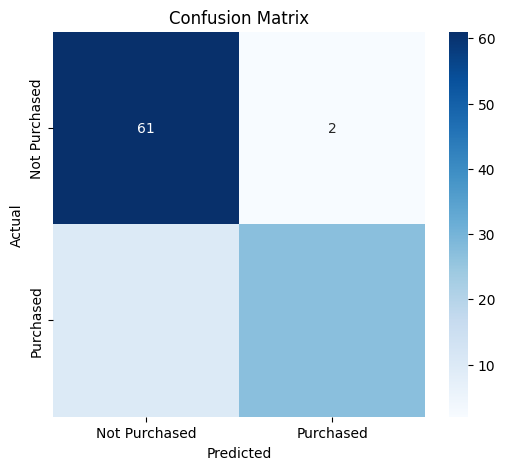

In [15]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Purchased", "Purchased"],
    yticklabels=["Not Purchased", "Purchased"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
# Accuracy Score

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy Score : {accuracy:.2f}")

Accuracy Score : 0.88


In [17]:
# Precision, Recall and F1-Score

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100



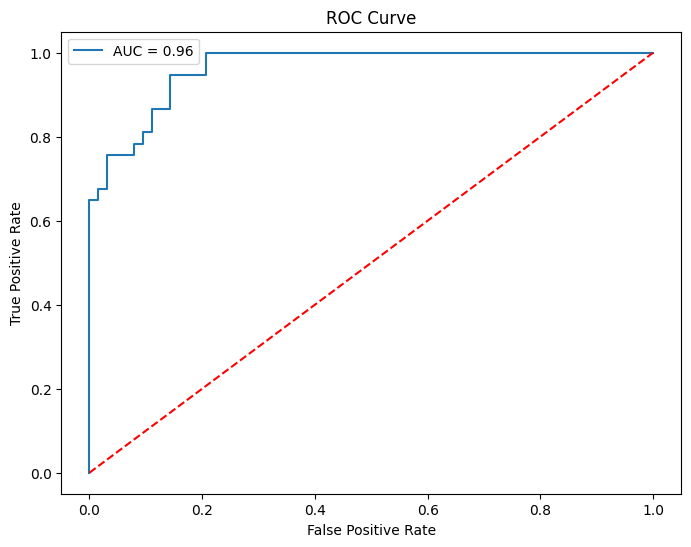

AUC Score : 0.96


In [18]:
# ROC Curve

from sklearn.metrics import roc_curve, roc_auc_score

y_score = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)

auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

print(f"AUC Score : {auc:.2f}")

In [19]:
# Predicting for a new customer

new_customer = [[1, 35, 60000]]

new_customer = scaler.transform(new_customer)

prediction = model.predict(new_customer)

probability = model.predict_proba(new_customer)

print("Prediction :", prediction[0])

print("Probability :", probability)

if prediction[0] == 1:
    print("The customer is likely to purchase the product.")
else:
    print("The customer is not likely to purchase the product.")

Prediction : 0
Probability : [[0.85594765 0.14405235]]
The customer is not likely to purchase the product.


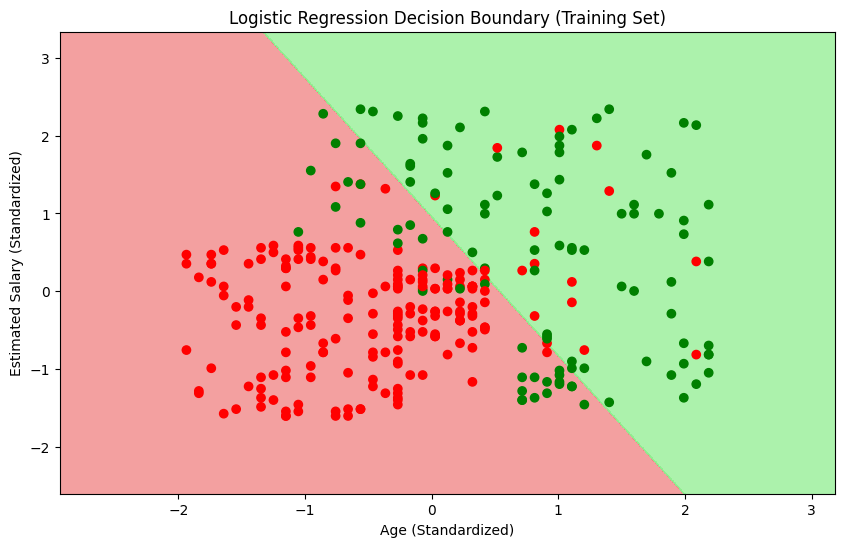

In [20]:
# Decision Boundary Visualization

from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:,1].min()-1,
              stop=X_set[:,1].max()+1,
              step=0.01),

    np.arange(start=X_set[:,2].min()-1,
              stop=X_set[:,2].max()+1,
              step=0.01)
)

plt.figure(figsize=(10,6))

plt.contourf(
    X1,
    X2,
    model.predict(
        np.array([X_set[:,0].mean()*np.ones(X1.ravel().shape),
                  X1.ravel(),
                  X2.ravel()]).T
    ).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(("lightcoral","lightgreen"))
)

plt.scatter(
    X_set[:,1],
    X_set[:,2],
    c=y_set,
    cmap=ListedColormap(("red","green"))
)

plt.title("Logistic Regression Decision Boundary (Training Set)")
plt.xlabel("Age (Standardized)")
plt.ylabel("Estimated Salary (Standardized)")

plt.show()